# Regression & Classification with Apache Spark MLlib

**Dataset**: E-commerce event log with columns: `event_type`, `product_id`, `brand`, `price`, `user_id`, `user_session`, `product_name`, `category`, `hour`, `day`, `month`, `year`

## Tasks
| Task | Type | Target | Algorithm |
|------|------|--------|-----------|
| Predict product **price** | Regression | `price` (continuous) | Linear Regression |
| Predict **event type** (purchase vs cart) | Classification | `event_type` (binary) | Logistic Regression |

## Pipeline
1. Spark Session
2. Load & Explore
3. Feature Engineering
4. **Regression** — predict `price` (Linear Regression)
5. **Classification** — predict `event_type` (Logistic Regression)
6. Evaluation & Visualizations


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler
)
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import (
    RegressionEvaluator, BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
spark = SparkSession.builder \
    .appName("Regression_Classification_Ecommerce") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")


In [ ]:
DATA_PATH = "part-00000-592294fe-0de3-464a-b8ed-3c5026285aa9-c000.csv"

df = spark.read.csv(DATA_PATH, header=True, inferSchema=True)
print(f"Rows    : {df.count():,}")
print(f"Columns : {df.columns}")
df.printSchema()

Rows    : 134,995
Columns : ['event_type', 'product_id', 'brand', 'price', 'user_id', 'user_session', 'product_name', 'category', 'hour', 'day', 'month', 'year']
root
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- year: integer (nullable = true)



In [ ]:
df.show(5)
df.select("price", "hour", "day", "month").describe().show()
print("\n=== event_type distribution ===")
df.groupBy("event_type").count().show()

print("\n=== Top categories ===")
df.groupBy("category").count().orderBy(F.desc("count")).show(10)

print("\n=== Top brands ===")
df.groupBy("brand").count().orderBy(F.desc("count")).show(10)

+----------+----------+-------+------+---------+--------------------+------------+-----------+----+---+-----+----+
|event_type|product_id|  brand| price|  user_id|        user_session|product_name|   category|hour|day|month|year|
+----------+----------+-------+------+---------+--------------------+------------+-----------+----+---+-----+----+
|  purchase|   1004856|samsung|130.76|543272936|8187d148-3c41-46d...|  smartphone|electronics|   0|  3|   10|2019|
|  purchase|   1002532|  apple|642.69|551377651|3c80f0d6-e9ec-418...|  smartphone|electronics|   0|  3|   10|2019|
|  purchase|  13800054|santeri| 54.42|555332717|1dea3ee2-2ded-42e...|    bathroom|  furniture|   0|  3|   10|2019|
|  purchase|   4804055|  apple|189.91|524601178|2af9b570-0942-4dc...|       audio|electronics|   0|  3|   10|2019|
|      cart|   1002524|  apple|515.67|524325294|0b74a829-f9d7-465...|  smartphone|electronics|   0|  3|   10|2019|
+----------+----------+-------+------+---------+--------------------+-----------

## 3. Feature Engineering (Shared)

Both models share the same feature set. We encode categorical columns (`brand`, `category`, `event_type`) using **StringIndexer → OneHotEncoder**, then assemble all features into a single vector.

In [ ]:
data = df.select(
    "event_type", "price", "brand", "category", "hour", "day", "month"
).dropna()

print(f"Rows after dropping nulls: {data.count():,}")

Rows after dropping nulls: 134,995


In [ ]:

# StringIndexer: converts string labels to numeric indices
brand_indexer    = StringIndexer(inputCol="brand",    outputCol="brand_idx",    handleInvalid="keep")
category_indexer = StringIndexer(inputCol="category", outputCol="category_idx", handleInvalid="keep")
event_indexer    = StringIndexer(inputCol="event_type",outputCol="label",        handleInvalid="keep")
# OneHotEncoder: converts indices to binary vectors
encoder = OneHotEncoder(
    inputCols=["brand_idx", "category_idx"],
    outputCols=["brand_vec", "category_vec"]
)

feature_cols = ["brand_vec", "category_vec", "hour", "day", "month"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

preprocessing = Pipeline(stages=[
    brand_indexer,
    category_indexer,
    event_indexer,
    encoder,
    assembler,
    scaler
])

preprocessor = preprocessing.fit(data)
prepared     = preprocessor.transform(data)

print("Preprocessing done. Sample output:")
prepared.select("event_type", "label", "price", "features").show(5, truncate=True)

Preprocessing done. Sample output:
+----------+-----+------+--------------------+
|event_type|label| price|            features|
+----------+-----+------+--------------------+
|  purchase|  2.0|130.76|(1036,[0,1020,103...|
|  purchase|  2.0|642.69|(1036,[1,1020,103...|
|  purchase|  2.0| 54.42|(1036,[298,1026,1...|
|  purchase|  2.0|189.91|(1036,[1,1020,103...|
|      cart|  1.0|515.67|(1036,[1,1020,103...|
+----------+-----+------+--------------------+
only showing top 5 rows


---
## 4. REGRESSION — Predict `price`

**Target**: `price` (continuous)  
**Features**: brand, category, hour, day, month  
**Model**: Linear Regression  
**Metrics**: RMSE, MAE, R²


In [ ]:
# Train / Test split
reg_data = prepared.select("features", "price").withColumnRenamed("price", "label")

reg_train, reg_test = reg_data.randomSplit([0.8, 0.2], seed=42)
print(f"Regression — Train: {reg_train.count():,}  |  Test: {reg_test.count():,}")

Regression — Train: 108,007  |  Test: 26,988


In [ ]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.1,
    elasticNetParam=0
)

lr_model = lr.fit(reg_train)

# Training summary
lr_summary = lr_model.summary
print(f"Linear Regression — Training RMSE : {lr_summary.rootMeanSquaredError:.4f}")
print(f"Linear Regression — Training R²   : {lr_summary.r2:.4f}")
print(f"Intercept : {lr_model.intercept:.4f}")

Linear Regression — Training RMSE : 284.4152
Linear Regression — Training R²   : 0.4882
Intercept : 359.5300


In [ ]:
# Evaluate
lr_preds = lr_model.transform(reg_test)

reg_evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
reg_evaluator_mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
reg_evaluator_r2   = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

lr_rmse = reg_evaluator_rmse.evaluate(lr_preds)
lr_mae  = reg_evaluator_mae.evaluate(lr_preds)
lr_r2   = reg_evaluator_r2.evaluate(lr_preds)

print("\n=== Linear Regression — Test Set Results ===")
print(f"  RMSE : {lr_rmse:.4f}")
print(f"  MAE  : {lr_mae:.4f}")
print(f"  R²   : {lr_r2:.4f}")

lr_preds.select("label", "prediction").show(10)


=== Linear Regression — Test Set Results ===
  RMSE : 284.6647
  MAE  : 177.0149
  R²   : 0.4796
+------+------------------+
| label|        prediction|
+------+------------------+
|286.86|320.31536012062264|
| 12.48| 320.9863725259254|
| 38.24| 320.9863725259254|
| 92.64| 320.9863725259254|
| 92.64| 320.9863725259254|
| 92.64| 320.9863725259254|
| 107.8| 320.9863725259254|
|130.73| 320.9863725259254|
|130.76| 320.9863725259254|
|130.76| 320.9863725259254|
+------+------------------+
only showing top 10 rows


---
## 5. CLASSIFICATION — Predict `event_type` (purchase vs cart)

**Target**: `event_type` → binary label (0 = cart, 1 = purchase)  
**Features**: brand, category, price, hour, day, month  
**Model**: Logistic Regression  
**Metrics**: Accuracy, Precision, Recall, F1, AUC-ROC


In [ ]:
assembler_clf = VectorAssembler(
    inputCols=["brand_vec", "category_vec", "price", "hour", "day", "month"],
    outputCol="features_raw_clf"
)
scaler_clf = StandardScaler(
    inputCol="features_raw_clf",
    outputCol="features_clf",
    withStd=True,
    withMean=False
)

# Filter  binary classification (
binary_clf_data = prepared.filter(F.col("event_type").isin("purchase", "cart"))

binary_label_indexer = StringIndexer(inputCol="event_type", outputCol="binary_label", handleInvalid="error")
binary_clf_data = binary_label_indexer.fit(binary_clf_data).transform(binary_clf_data)
clf_prep = Pipeline(stages=[assembler_clf, scaler_clf]).fit(binary_clf_data)
clf_data = clf_prep.transform(binary_clf_data).select("features_clf", "binary_label")
clf_data = clf_data.withColumnRenamed("features_clf", "features").withColumnRenamed("binary_label", "label")

clf_train, clf_test = clf_data.randomSplit([0.8, 0.2], seed=42)
print(f"Classification — Train: {clf_train.count():,}  |  Test: {clf_test.count():,}")

print("\nClass distribution in training set:")
clf_train.groupBy("label").count().show()

Classification — Train: 19,786  |  Test: 4,911

Class distribution in training set:
+-----+-----+
|label|count|
+-----+-----+
|  1.0| 9720|
|  0.0|10066|
+-----+-----+



###Logistic Regression


In [ ]:
log_reg = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.1,
    elasticNetParam=0,

)

log_reg_model = log_reg.fit(clf_train)

# Training summary
lr_clf_summary = log_reg_model.summary
print(f"Logistic Regression — Training Accuracy : {lr_clf_summary.accuracy:.4f}")
print(f"Logistic Regression — Training AUC-ROC  : {lr_clf_summary.areaUnderROC:.4f}")

Logistic Regression — Training Accuracy : 0.6174
Logistic Regression — Training AUC-ROC  : 0.6414


In [ ]:
# Evaluate on test set
log_reg_preds = log_reg_model.transform(clf_test)

bin_evaluator   = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
mc_evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
mc_evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
mc_evaluator_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
mc_evaluator_rec  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

def evaluate_classifier(preds, name):
    auc  = bin_evaluator.evaluate(preds)
    acc  = mc_evaluator_acc.evaluate(preds)
    f1   = mc_evaluator_f1.evaluate(preds)
    prec = mc_evaluator_prec.evaluate(preds)
    rec  = mc_evaluator_rec.evaluate(preds)
    print(f"\n=== {name} — Test Set Results ===")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC-ROC": auc}

lr_clf_metrics = evaluate_classifier(log_reg_preds, "Logistic Regression")

print("\nSample Predictions:")
log_reg_preds.select("label", "prediction", "probability").show(10)


=== Logistic Regression — Test Set Results ===
  Accuracy  : 0.6031
  Precision : 0.6753
  Recall    : 0.6031
  F1 Score  : 0.5573
  AUC-ROC   : 0.6285

Sample Predictions:
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  1.0|       0.0|[0.57373343059943...|
|  1.0|       0.0|[0.58737281869691...|
|  0.0|       0.0|[0.59224456362270...|
|  0.0|       0.0|[0.59207595844826...|
|  1.0|       0.0|[0.56448645142382...|
|  1.0|       0.0|[0.58933220953131...|
|  1.0|       0.0|[0.55507650428628...|
|  1.0|       0.0|[0.56622508207119...|
|  0.0|       0.0|[0.58006585951718...|
|  0.0|       0.0|[0.58006585951718...|
+-----+----------+--------------------+
only showing top 10 rows


###  Confusion Matrix


In [ ]:
def confusion_matrix_spark(preds, model_name):
    """Compute and display confusion matrix from Spark predictions."""
    cm = preds.groupBy("label", "prediction").count().orderBy("label", "prediction").toPandas()
    print(f"\n=== Confusion Matrix — {model_name} ===")
    print(cm.to_string(index=False))
    return cm

lr_cm = confusion_matrix_spark(log_reg_preds, "Logistic Regression")



=== Confusion Matrix — Logistic Regression ===
 label  prediction  count
   0.0         0.0   2272
   0.0         1.0    186
   1.0         0.0   1763
   1.0         1.0    690


---
## 6. Visualizations


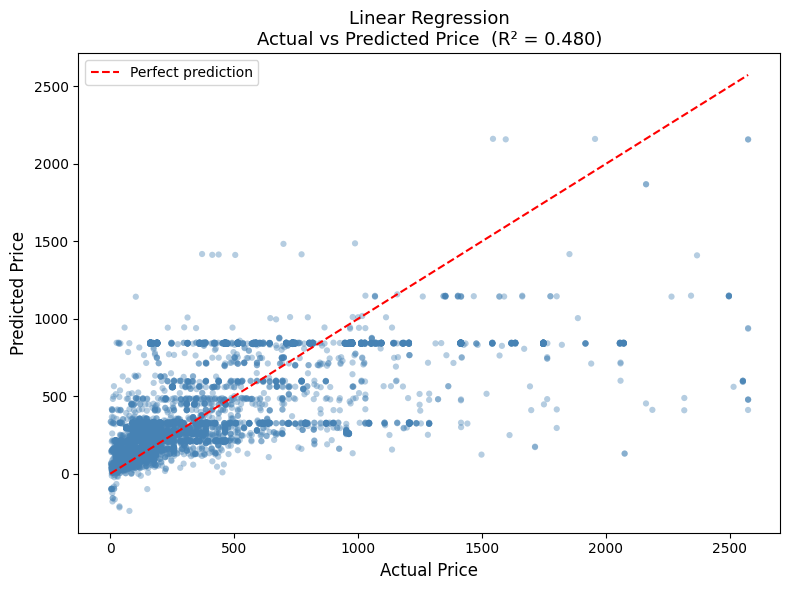

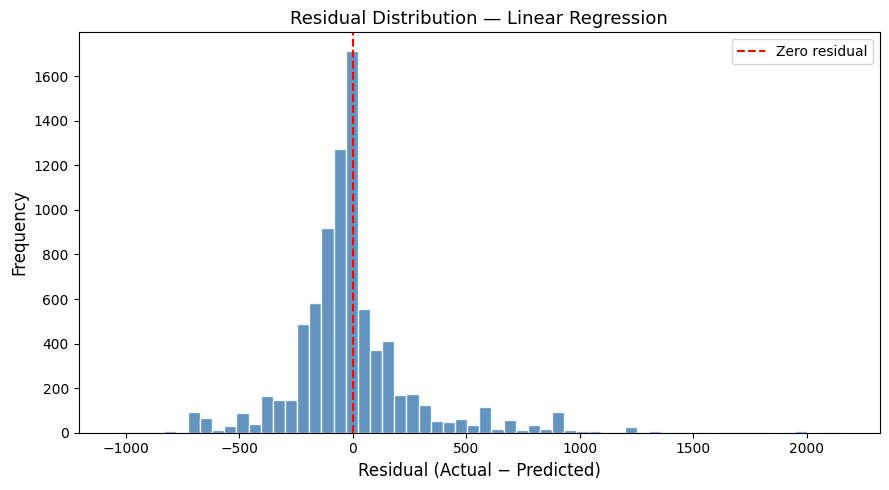

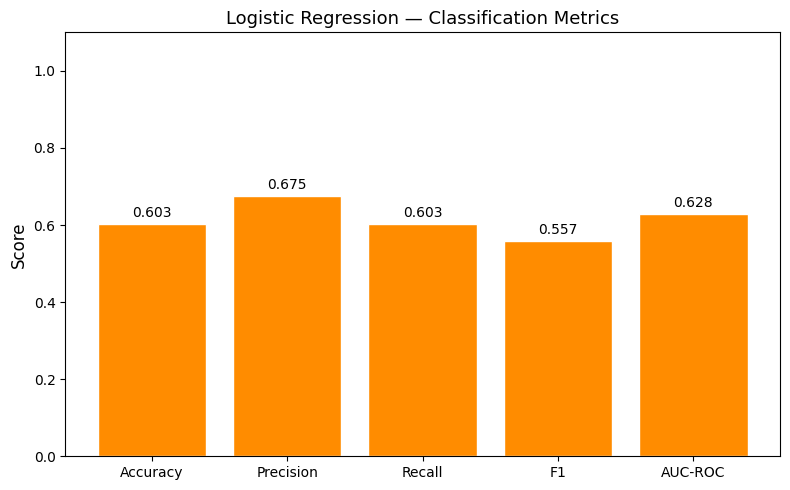

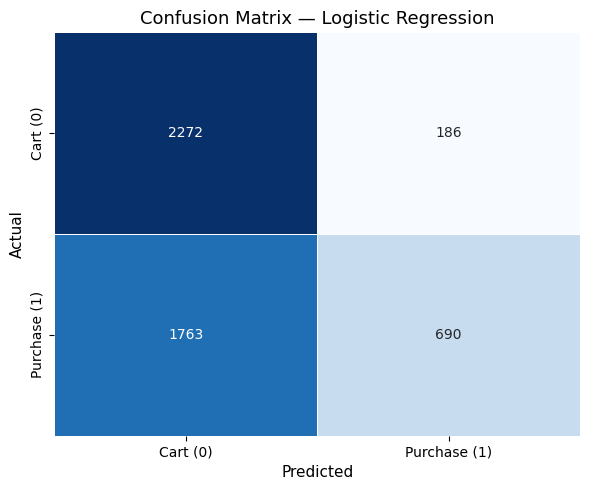

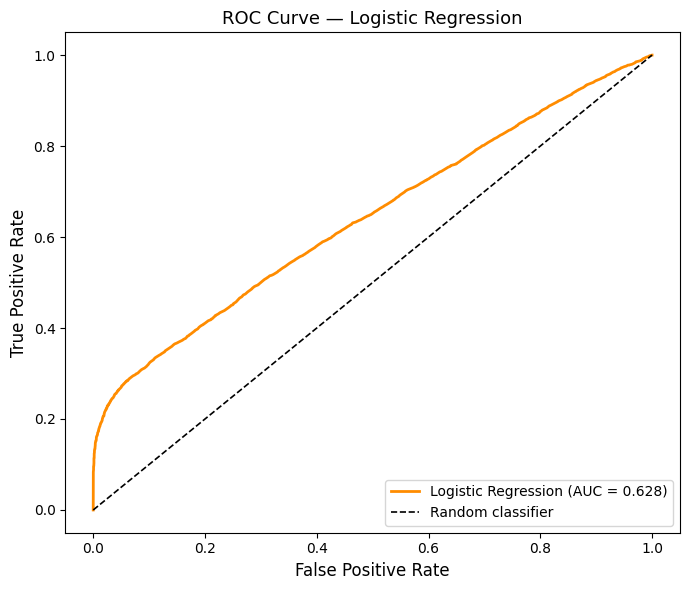

In [ ]:
# ── Plot 1: Actual vs Predicted Price (Linear Regression) ────────────────────
preds_pd = lr_preds.select("label", "prediction").sample(fraction=0.3, seed=42).toPandas()

plt.figure(figsize=(8, 6))
plt.scatter(preds_pd["label"], preds_pd["prediction"], alpha=0.4, edgecolors='none', color='steelblue', s=20)
max_val = max(preds_pd["label"].max(), preds_pd["prediction"].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.title(f"Linear Regression\nActual vs Predicted Price  (R² = {lr_r2:.3f})", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("reg_actual_vs_predicted.png", dpi=150)
plt.show()

# ── Plot 2: Residuals Distribution ───────────────────────────────────────────
preds_pd["residual"] = preds_pd["label"] - preds_pd["prediction"]

plt.figure(figsize=(9, 5))
plt.hist(preds_pd["residual"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero residual")
plt.xlabel("Residual (Actual − Predicted)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Residual Distribution — Linear Regression", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("reg_residuals.png", dpi=150)
plt.show()

# ── Plot 3: Classification Metrics Bar Chart ──────────────────────────────────
metrics = {"Accuracy": lr_clf_metrics["Accuracy"], "Precision": lr_clf_metrics["Precision"],
           "Recall": lr_clf_metrics["Recall"], "F1": lr_clf_metrics["F1"], "AUC-ROC": lr_clf_metrics["AUC-ROC"]}

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics.keys(), metrics.values(), color="darkorange", edgecolor="white")
plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
plt.ylim(0, 1.1)
plt.ylabel("Score", fontsize=12)
plt.title("Logistic Regression — Classification Metrics", fontsize=13)
plt.tight_layout()
plt.savefig("clf_metrics.png", dpi=150)
plt.show()

# ── Plot 4: Confusion Matrix Heatmap ─────────────────────────────────────────
import numpy as np

def cm_to_matrix(cm_pd):
    mat = np.zeros((2, 2), dtype=int)
    for _, row in cm_pd.iterrows():
        mat[int(row['label'])][int(row['prediction'])] += int(row['count'])
    return mat

mat = cm_to_matrix(lr_cm)
labels = ["Cart (0)", "Purchase (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5, cbar=False)
plt.title("Confusion Matrix — Logistic Regression", fontsize=13)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ── Plot 5: ROC Curve ─────────────────────────────────────────────────────────
roc_pd = lr_clf_summary.roc.toPandas()

plt.figure(figsize=(7, 6))
plt.plot(roc_pd["FPR"], roc_pd["TPR"], color='darkorange', lw=2,
         label=f"Logistic Regression (AUC = {lr_clf_metrics['AUC-ROC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label="Random classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Logistic Regression", fontsize=13)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()


In [ ]:
reg_results_df = pd.DataFrame([{
    "Model": "Linear Regression", "RMSE": lr_rmse, "MAE": lr_mae, "R2": lr_r2
}])
clf_results_df = pd.DataFrame([lr_clf_metrics])

reg_results_df.to_csv("regression_results.csv", index=False)
clf_results_df.to_csv("classification_results.csv", index=False)

Saved: regression_results.csv
Saved: classification_results.csv
Spark session stopped.


---
# Association Rule Mining with Apriori (FP-Growth) in Apache Spark

This notebook applies association rule mining on an e-commerce dataset using **PySpark's FP-Growth**, which produces the same output as Apriori (frequent itemsets + association rules) but is optimized for distributed environments.

> **Dataset**: E-commerce event log (~135K rows) with columns: `event_type`, `product_id`, `brand`, `price`, `user_id`, `user_session`, `product_name`, `category`, `hour`, `day`, `month`, `year`

## Pipeline Overview
1. Initialize Spark Session
2. Load & Explore Data
3. Preprocess — build market baskets (transactions per user session)
4. Run FP-Growth (Apriori equivalent)
5. Explore Frequent Itemsets
6. Explore Association Rules
7. Filter & Interpret results
8. Visualize top rules

In [ ]:
# Distribution of event types
print("=== Event Type Distribution ===")
df.groupBy("event_type").count().orderBy(F.desc("count")).show()

# Unique counts
print("=== Unique Counts ===")
for col_name in ["user_id", "user_session", "product_id", "brand", "category"]:
    print(f"  {col_name:15s}: {df.select(col_name).distinct().count():,}")

=== Event Type Distribution ===
+----------+------+
|event_type| count|
+----------+------+
|      view|110298|
|      cart| 12524|
|  purchase| 12173|
+----------+------+

=== Unique Counts ===
  user_id        : 58,526
  user_session   : 70,609
  product_id     : 14,500
  brand          : 1,020
  category       : 13


In [ ]:
# Options: 'product_name', 'brand', 'category'
ITEM_COLUMN = "product_name"

EVENT_FILTER = "purchase"   # or "cart" or None
MIN_BASKET_SIZE = 2

if EVENT_FILTER:
    events = df.filter(F.col("event_type") == EVENT_FILTER)
    print(f"Filtered to '{EVENT_FILTER}' events: {events.count():,} rows")
else:
    events = df
    print(f"Using all events: {events.count():,} rows")

Filtered to 'purchase' events: 12,173 rows


In [ ]:
events = events.dropna(subset=["user_session", ITEM_COLUMN])

#  Build baskets
baskets = (
    events
    .groupBy("user_session")
    .agg(F.collect_set(ITEM_COLUMN).alias("items"))
    .filter(F.size("items") >= MIN_BASKET_SIZE)
)

basket_count = baskets.count()
print(f"Total transactions (baskets) with >= {MIN_BASKET_SIZE} items: {basket_count:,}")
baskets.show(5, truncate=False)

Total transactions (baskets) with >= 2 items: 207
+------------------------------------+-----------------------------------------+
|user_session                        |items                                    |
+------------------------------------+-----------------------------------------+
|04359e34-d6ae-474c-b03e-d37b10eb0d0a|[environment, kitchen]                   |
|0849819b-dadd-450c-b512-eee7fb8bfad3|[smartphone, accessories]                |
|0eedef43-b496-46a8-a027-70bdb0c1ed22|[smartphone, video, environment, kitchen]|
|1017e674-8a31-4a2f-914c-02407bda9941|[video, environment]                     |
|110605e0-6bb4-498f-8a30-652acbc498b1|[ironing_board, tools]                   |
+------------------------------------+-----------------------------------------+
only showing top 5 rows


In [ ]:
# Basket size distribution
basket_sizes = baskets.withColumn("basket_size", F.size("items"))

print("=== Basket Size Distribution ===")
basket_sizes.groupBy("basket_size") \
    .count() \
    .orderBy("basket_size") \
    .show(20)

print("\n=== Basket Size Stats ===")
basket_sizes.select(
    F.min("basket_size").alias("min"),
    F.max("basket_size").alias("max"),
    F.avg("basket_size").alias("mean"),
    F.expr("percentile_approx(basket_size, 0.5)").alias("median")
).show()

=== Basket Size Distribution ===
+-----------+-----+
|basket_size|count|
+-----------+-----+
|          2|  197|
|          3|    9|
|          4|    1|
+-----------+-----+


=== Basket Size Stats ===
+---+---+------------------+------+
|min|max|              mean|median|
+---+---+------------------+------+
|  2|  4|2.0531400966183573|     2|
+---+---+------------------+------+



## 4. Apply FP-Growth (Apriori Equivalent in Spark)

Spark MLlib provides **FP-Growth** which mines the same frequent itemsets and association rules as Apriori, but more efficiently via the FP-tree data structure.

Key parameters:
- **`minSupport`**: Minimum fraction of transactions that must contain an itemset for it to be considered frequent. e.g. `0.01` = must appear in at least 1% of sessions.
- **`minConfidence`**: Minimum confidence for an association rule. e.g. `0.3` = rule is correct 30% of the time its antecedent occurs.

In [ ]:

MIN_SUPPORT    = 0.01   # 1% of sessions — lower = more itemsets but slower
MIN_CONFIDENCE = 0.30   # 30% confidence threshold for rules
# ──────────────────────────────────────────────────────────────────────────────

fpgrowth = FPGrowth(
    itemsCol="items",
    minSupport=MIN_SUPPORT,
    minConfidence=MIN_CONFIDENCE
)

print(f"Running FP-Growth with minSupport={MIN_SUPPORT}, minConfidence={MIN_CONFIDENCE}...")
model = fpgrowth.fit(baskets)
print("Done!")

Running FP-Growth with minSupport=0.01, minConfidence=0.3...
Done!


## 5. Frequent Itemsets

In [ ]:
freq_itemsets = model.freqItemsets

total_itemsets = freq_itemsets.count()
print(f"Total frequent itemsets found: {total_itemsets:,}")

freq_itemsets = freq_itemsets \
    .withColumn("itemset_size", F.size("items")) \
    .withColumn("support", F.col("freq") / basket_count)

print("\n=== Frequent Itemsets by Size ===")
freq_itemsets.groupBy("itemset_size").count().orderBy("itemset_size").show()

print("\n=== Top 20 Most Frequent Itemsets ===")
freq_itemsets.orderBy(F.desc("freq")).show(20, truncate=False)

Total frequent itemsets found: 39

=== Frequent Itemsets by Size ===
+------------+-----+
|itemset_size|count|
+------------+-----+
|           1|   16|
|           2|   23|
+------------+-----+


=== Top 20 Most Frequent Itemsets ===
+-------------------------+----+------------+--------------------+
|items                    |freq|itemset_size|support             |
+-------------------------+----+------------+--------------------+
|[smartphone]             |124 |1           |0.5990338164251208  |
|[kitchen]                |58  |1           |0.28019323671497587 |
|[audio]                  |43  |1           |0.20772946859903382 |
|[notebook]               |33  |1           |0.15942028985507245 |
|[environment]            |31  |1           |0.1497584541062802  |
|[video]                  |29  |1           |0.14009661835748793 |
|[clocks]                 |29  |1           |0.14009661835748793 |
|[audio, smartphone]      |28  |2           |0.13526570048309178 |
|[kitchen, smartphone]    |2

In [ ]:
# Top single items (1-itemsets)
print("=== Top 15 Most Frequent Individual Items ===")
freq_itemsets \
    .filter(F.col("itemset_size") == 1) \
    .orderBy(F.desc("freq")) \
    .show(15, truncate=False)

# Top pairs (2-itemsets)
print("\n=== Top 15 Most Frequent Item Pairs ===")
freq_itemsets \
    .filter(F.col("itemset_size") == 2) \
    .orderBy(F.desc("freq")) \
    .show(15, truncate=False)

# Top triples (3-itemsets), if any
print("\n=== Top 10 Most Frequent Item Triples (3-itemsets) ===")
freq_itemsets \
    .filter(F.col("itemset_size") == 3) \
    .orderBy(F.desc("freq")) \
    .show(10, truncate=False)

=== Top 15 Most Frequent Individual Items ===
+---------------+----+------------+--------------------+
|items          |freq|itemset_size|support             |
+---------------+----+------------+--------------------+
|[smartphone]   |124 |1           |0.5990338164251208  |
|[kitchen]      |58  |1           |0.28019323671497587 |
|[audio]        |43  |1           |0.20772946859903382 |
|[notebook]     |33  |1           |0.15942028985507245 |
|[environment]  |31  |1           |0.1497584541062802  |
|[video]        |29  |1           |0.14009661835748793 |
|[clocks]       |29  |1           |0.14009661835748793 |
|[peripherals]  |9   |1           |0.043478260869565216|
|[tools]        |8   |1           |0.03864734299516908 |
|[iron]         |8   |1           |0.03864734299516908 |
|[tablet]       |7   |1           |0.033816425120772944|
|[desktop]      |7   |1           |0.033816425120772944|
|[telephone]    |7   |1           |0.033816425120772944|
|[accessories]  |7   |1           |0.03381

## 6. Association Rules

In [ ]:
rules = model.associationRules

total_rules = rules.count()
print(f"Total association rules found: {total_rules:,}")

print("\n=== Association Rules Schema ===")
rules.printSchema()

# antecedent  → consequent  [support, confidence, lift]
print("\n=== Sample Rules ===")
rules.show(10, truncate=False)

Total association rules found: 17

=== Association Rules Schema ===
root
 |-- antecedent: array (nullable = false)
 |    |-- element: string (containsNull = false)
 |-- consequent: array (nullable = false)
 |    |-- element: string (containsNull = false)
 |-- confidence: double (nullable = false)
 |-- lift: double (nullable = true)
 |-- support: double (nullable = false)


=== Sample Rules ===
+-------------+------------+-------------------+------------------+--------------------+
|antecedent   |consequent  |confidence         |lift              |support             |
+-------------+------------+-------------------+------------------+--------------------+
|[tools]      |[smartphone]|0.375              |0.626008064516129 |0.014492753623188406|
|[accessories]|[smartphone]|0.42857142857142855|0.7154377880184332|0.014492753623188406|
|[accessories]|[audio]     |0.42857142857142855|2.0631229235880397|0.014492753623188406|
|[environment]|[kitchen]   |0.5161290322580645 |1.8420467185761955|0.

In [ ]:

# support    = P(A ∩ B)  — how often A and B appear together
# confidence = P(B | A)  — given A, how often is B also bought?
# lift  = confidence / P(B) — > 1 means A and B are positively correlated


print("=== Top 20 Rules by Lift (Strongest Associations) ===")
rules \
    .orderBy(F.desc("lift")) \
    .show(20, truncate=False)

print("\n=== Top 20 Rules by Confidence ===")
rules \
    .orderBy(F.desc("confidence")) \
    .show(20, truncate=False)

=== Top 20 Rules by Lift (Strongest Associations) ===
+-------------+------------+-------------------+------------------+--------------------+
|antecedent   |consequent  |confidence         |lift              |support             |
+-------------+------------+-------------------+------------------+--------------------+
|[peripherals]|[notebook]  |0.5555555555555556 |3.4848484848484853|0.024154589371980676|
|[desktop]    |[notebook]  |0.42857142857142855|2.688311688311688 |0.014492753623188406|
|[tablet]     |[notebook]  |0.42857142857142855|2.688311688311688 |0.014492753623188406|
|[accessories]|[audio]     |0.42857142857142855|2.0631229235880397|0.014492753623188406|
|[environment]|[kitchen]   |0.5161290322580645 |1.8420467185761955|0.07729468599033816 |
|[iron]       |[kitchen]   |0.375              |1.3383620689655171|0.014492753623188406|
|[shoes]      |[smartphone]|0.75               |1.252016129032258 |0.014492753623188406|
|[telephone]  |[smartphone]|0.7142857142857143 |1.192396

In [ ]:
# Rules summary statistics
print("=== Rule Metrics Summary ===")
rules.select(
    F.min("confidence").alias("conf_min"),
    F.max("confidence").alias("conf_max"),
    F.avg("confidence").alias("conf_avg"),
    F.min("lift").alias("lift_min"),
    F.max("lift").alias("lift_max"),
    F.avg("lift").alias("lift_avg"),
    F.min("support").alias("supp_min"),
    F.max("support").alias("supp_max"),
).show()

=== Rule Metrics Summary ===
+------------------+--------+-----------------+------------------+------------------+------------------+--------------------+-------------------+
|          conf_min|conf_max|         conf_avg|          lift_min|          lift_max|          lift_avg|            supp_min|           supp_max|
+------------------+--------+-----------------+------------------+------------------+------------------+--------------------+-------------------+
|0.3620689655172414|    0.75|0.505987325488854|0.6044215795328143|3.4848484848484853|1.4060641720007594|0.014492753623188406|0.13526570048309178|
+------------------+--------+-----------------+------------------+------------------+------------------+--------------------+-------------------+



## 7. Filter & Refine Rules

Apply additional filters to keep only the most actionable rules.

In [ ]:
# lift > 1 (positive correlation) AND confidence >= 0.4
LIFT_THRESHOLD       = 1.0
CONFIDENCE_THRESHOLD = 0.40

strong_rules = rules.filter(
    (F.col("lift") > LIFT_THRESHOLD) &
    (F.col("confidence") >= CONFIDENCE_THRESHOLD)
)

print(f"Strong rules (lift > {LIFT_THRESHOLD}, confidence >= {CONFIDENCE_THRESHOLD}): {strong_rules.count()}")
strong_rules.orderBy(F.desc("lift")).show(20, truncate=False)

Strong rules (lift > 1.0, confidence >= 0.4): 8
+-------------+------------+-------------------+------------------+--------------------+
|antecedent   |consequent  |confidence         |lift              |support             |
+-------------+------------+-------------------+------------------+--------------------+
|[peripherals]|[notebook]  |0.5555555555555556 |3.4848484848484853|0.024154589371980676|
|[desktop]    |[notebook]  |0.42857142857142855|2.688311688311688 |0.014492753623188406|
|[tablet]     |[notebook]  |0.42857142857142855|2.688311688311688 |0.014492753623188406|
|[accessories]|[audio]     |0.42857142857142855|2.0631229235880397|0.014492753623188406|
|[environment]|[kitchen]   |0.5161290322580645 |1.8420467185761955|0.07729468599033816 |
|[shoes]      |[smartphone]|0.75               |1.252016129032258 |0.014492753623188406|
|[telephone]  |[smartphone]|0.7142857142857143 |1.1923963133640554|0.024154589371980676|
|[audio]      |[smartphone]|0.6511627906976745 |1.087021755438

In [ ]:
rules_pd = rules \
    .withColumn("antecedent_str", F.concat_ws(" + ", "antecedent")) \
    .withColumn("consequent_str", F.concat_ws(" + ", "consequent")) \
    .select("antecedent_str", "consequent_str", "support", "confidence", "lift") \
    .toPandas()

print(f"Rules collected to Pandas: {len(rules_pd)} rows")
rules_pd.sort_values("lift", ascending=False).head(10)

Rules collected to Pandas: 17 rows


,antecedent_str,consequent_str,support,confidence,lift
11,peripherals,notebook,0.024155,0.555556,3.484848
14,tablet,notebook,0.014493,0.428571,2.688312
7,desktop,notebook,0.014493,0.428571,2.688312
2,accessories,audio,0.014493,0.428571,2.063123
3,environment,kitchen,0.077295,0.516129,1.842047
16,iron,kitchen,0.014493,0.375000,1.338362
4,shoes,smartphone,0.014493,0.750000,1.252016
8,telephone,smartphone,0.024155,0.714286,1.192396
15,audio,smartphone,0.135266,0.651163,1.087022
10,clocks,smartphone,0.082126,0.586207,0.978587


## 8. Visualizations

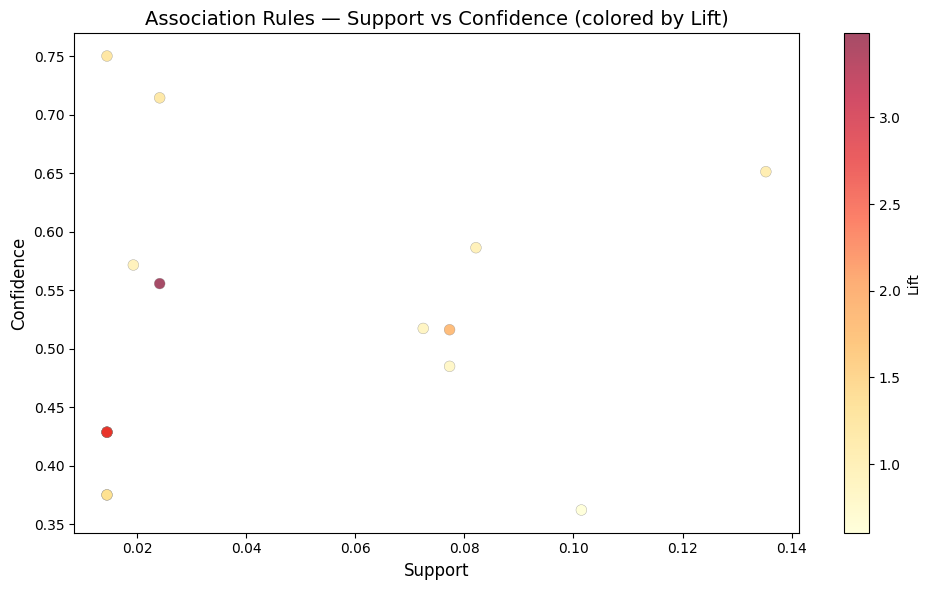

Saved: rules_scatter.png


In [ ]:
#  Support vs Confidence
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    rules_pd["support"],
    rules_pd["confidence"],
    c=rules_pd["lift"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="grey",
    linewidths=0.3,
    s=60
)
plt.colorbar(sc, label="Lift")
plt.xlabel("Support", fontsize=12)
plt.ylabel("Confidence", fontsize=12)
plt.title("Association Rules — Support vs Confidence (colored by Lift)", fontsize=14)
plt.tight_layout()
plt.savefig("rules_scatter.png", dpi=150)
plt.show()
print("Saved: rules_scatter.png")

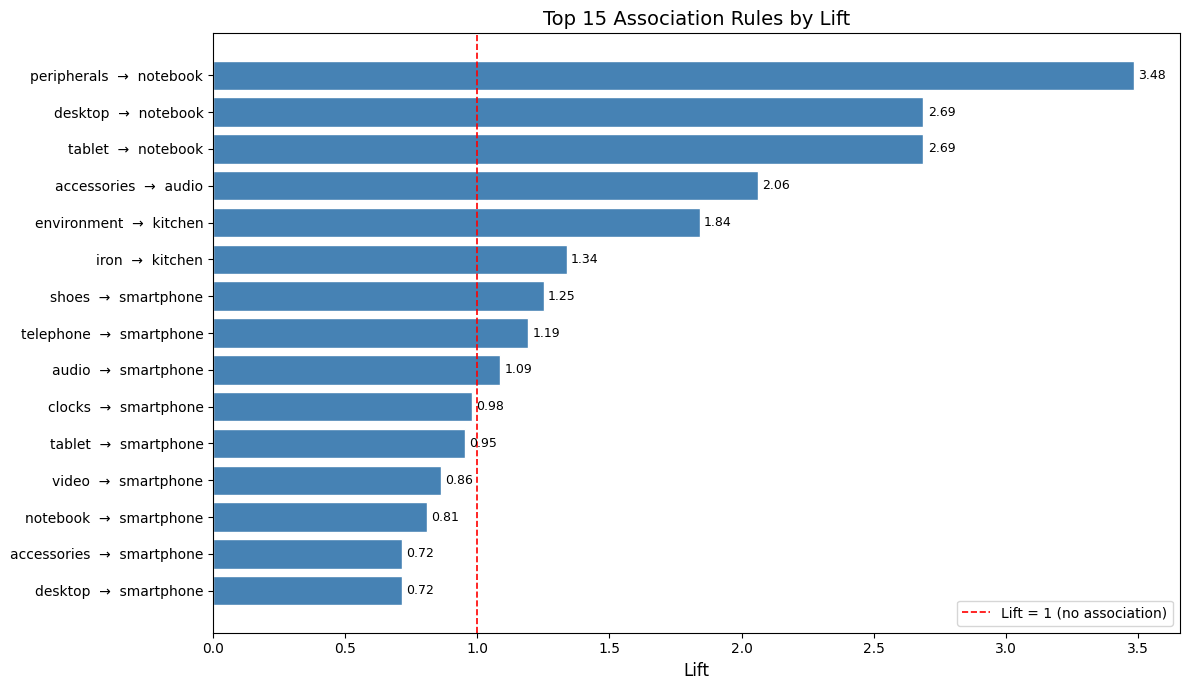

Saved: top15_rules_lift.png


In [ ]:
# Top 15 Rules by Lift horizontal bar chart
top15 = rules_pd.nlargest(15, "lift").copy()
top15["rule"] = top15["antecedent_str"] + "  →  " + top15["consequent_str"]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15["rule"], top15["lift"], color="steelblue", edgecolor="white")
ax.axvline(x=1, color="red", linestyle="--", linewidth=1.2, label="Lift = 1 (no association)")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlabel("Lift", fontsize=12)
ax.set_title("Top 15 Association Rules by Lift", fontsize=14)
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig("top15_rules_lift.png", dpi=150)
plt.show()
print("Saved: top15_rules_lift.png")

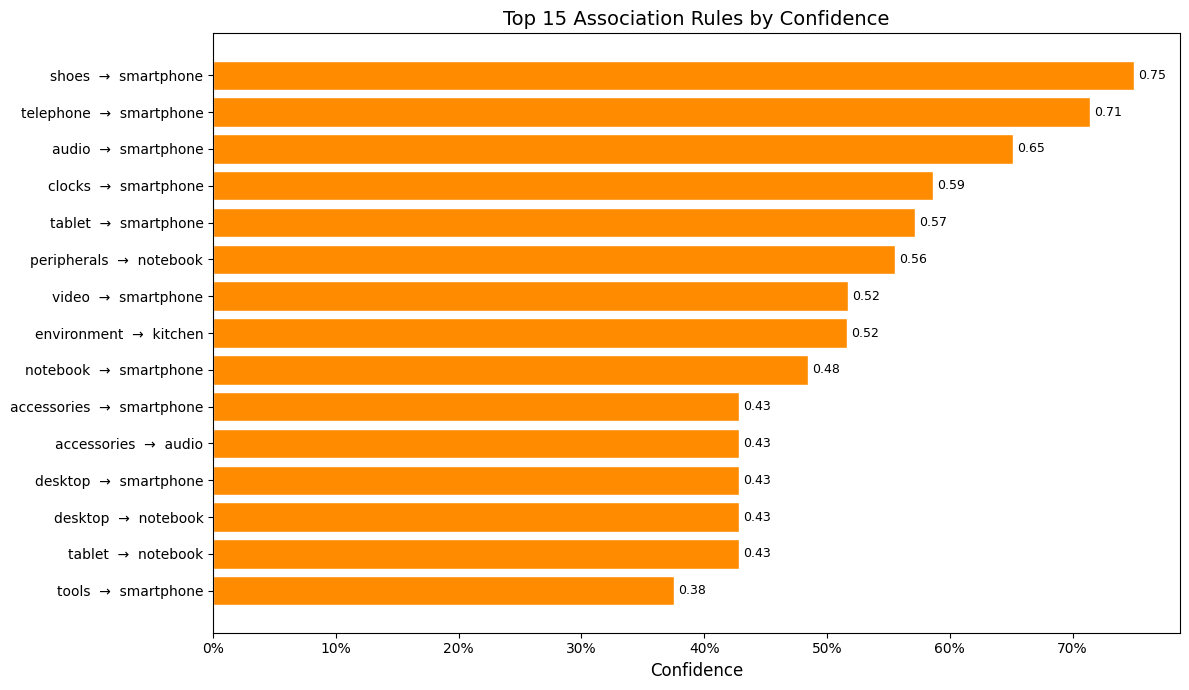

Saved: top15_rules_confidence.png


In [ ]:
top15_conf = rules_pd.nlargest(15, "confidence").copy()
top15_conf["rule"] = top15_conf["antecedent_str"] + "  →  " + top15_conf["consequent_str"]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_conf["rule"], top15_conf["confidence"], color="darkorange", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Confidence", fontsize=12)
ax.set_title("Top 15 Association Rules by Confidence", fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("top15_rules_confidence.png", dpi=150)
plt.show()
print("Saved: top15_rules_confidence.png")

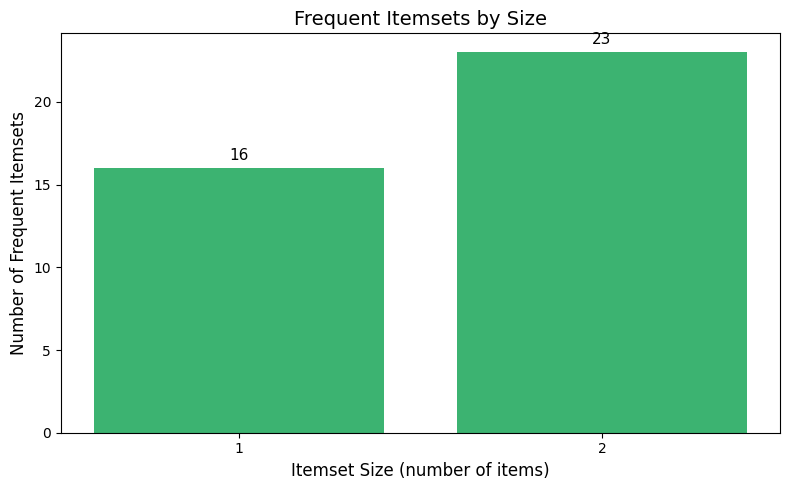

Saved: itemset_size_distribution.png


In [ ]:
# Frequent Itemsets
size_counts = freq_itemsets \
    .groupBy("itemset_size") \
    .count() \
    .orderBy("itemset_size") \
    .toPandas()

plt.figure(figsize=(8, 5))
plt.bar(size_counts["itemset_size"].astype(str), size_counts["count"], color="mediumseagreen")
plt.xlabel("Itemset Size (number of items)", fontsize=12)
plt.ylabel("Number of Frequent Itemsets", fontsize=12)
plt.title("Frequent Itemsets by Size", fontsize=14)
for i, row in size_counts.iterrows():
    plt.text(i, row["count"] + 0.5, str(row["count"]), ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("itemset_size_distribution.png", dpi=150)
plt.show()
print("Saved: itemset_size_distribution.png")

## 9. Experiment: Mine at Category Level

Re-run the pipeline using `category` instead of `product_name` for coarser, more interpretable rules.

In [ ]:
# Build category-level baskets
cat_baskets = (
    events
    .dropna(subset=["user_session", "category"])
    .groupBy("user_session")
    .agg(F.collect_set("category").alias("items"))
    .filter(F.size("items") >= 2)
)

cat_count = cat_baskets.count()
print(f"Category-level transactions: {cat_count:,}")

# FP-Growth on categories with lower support (fewer unique categories → can lower threshold)
fp_cat = FPGrowth(itemsCol="items", minSupport=0.005, minConfidence=0.2)
model_cat = fp_cat.fit(cat_baskets)

print("\n=== Frequent Category Itemsets ===")
model_cat.freqItemsets \
    .withColumn("support", F.col("freq") / cat_count) \
    .orderBy(F.desc("freq")) \
    .show(20, truncate=False)

print("\n=== Category Association Rules (by Lift) ===")
model_cat.associationRules \
    .orderBy(F.desc("lift")) \
    .show(20, truncate=False)

Category-level transactions: 106

=== Frequent Category Itemsets ===
+------------------------------------+----+--------------------+
|items                               |freq|support             |
+------------------------------------+----+--------------------+
|[electronics]                       |92  |0.8679245283018868  |
|[appliances]                        |57  |0.5377358490566038  |
|[appliances, electronics]           |45  |0.42452830188679247 |
|[computers]                         |34  |0.32075471698113206 |
|[computers, electronics]            |27  |0.25471698113207547 |
|[computers, appliances]             |7   |0.0660377358490566  |
|[construction]                      |7   |0.0660377358490566  |
|[auto]                              |7   |0.0660377358490566  |
|[auto, electronics]                 |7   |0.0660377358490566  |
|[kids]                              |5   |0.04716981132075472 |
|[construction, electronics]         |4   |0.03773584905660377 |
|[furniture]         

## 10. Save Results

In [ ]:
freq_itemsets_pd = freq_itemsets \
    .withColumn("items_str", F.concat_ws(" | ", "items")) \
    .select("items_str", "freq", "support", "itemset_size") \
    .toPandas()

freq_itemsets_pd.to_csv("frequent_itemsets.csv", index=False)
rules_pd.to_csv("association_rules.csv", index=False)

print(f"Saved {len(freq_itemsets_pd)} frequent itemsets → frequent_itemsets.csv")
print(f"Saved {len(rules_pd)} association rules   → association_rules.csv")

rules_pd.sort_values("lift", ascending=False).head(10)

Saved 39 frequent itemsets → frequent_itemsets.csv
Saved 17 association rules   → association_rules.csv


,antecedent_str,consequent_str,support,confidence,lift
11,peripherals,notebook,0.024155,0.555556,3.484848
14,tablet,notebook,0.014493,0.428571,2.688312
7,desktop,notebook,0.014493,0.428571,2.688312
2,accessories,audio,0.014493,0.428571,2.063123
3,environment,kitchen,0.077295,0.516129,1.842047
16,iron,kitchen,0.014493,0.375000,1.338362
4,shoes,smartphone,0.014493,0.750000,1.252016
8,telephone,smartphone,0.024155,0.714286,1.192396
15,audio,smartphone,0.135266,0.651163,1.087022
10,clocks,smartphone,0.082126,0.586207,0.978587


In [ ]:
spark.stop()

Spark session stopped.
